In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from bcNMF import nmf_sse, contrastive_nmf_sse

## Load data

Synthetic 28×28 images that mirror the MNIST + ImageNet setup (Section 2.2).  
**Target:** digit composited on texture via `max(digit, 0.8 × background)`.  
**Background:** texture images only, no digit.

In [32]:
X_target     = pd.read_csv('demo_data/target_images.csv',     index_col=0).values  # (784, 200)
X_background = pd.read_csv('demo_data/background_images.csv', index_col=0).values  # (784, 150)
labels       = pd.read_csv('demo_data/target_labels.csv')['digit'].values           # (200,)

print(f'Target     : {X_target.shape}')
print(f'Background : {X_background.shape}')
print(f'Labels     : {np.bincount(labels)} samples per digit')

Target     : (784, 200)
Background : (784, 150)
Labels     : [100 100] samples per digit


## Target dataset — example images

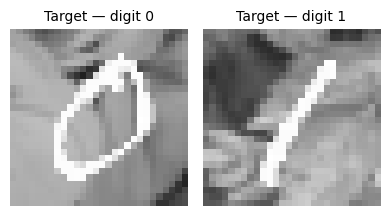

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2.2))
for d, ax in enumerate(axes):
    idx = np.where(labels == d)[0][0]
    ax.imshow(X_target[:, idx].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Target — digit {d}', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Background dataset — example images

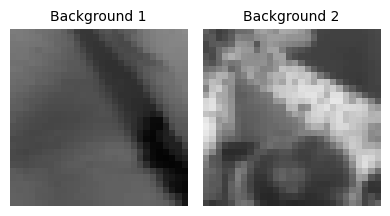

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2.2))
for i, ax in enumerate(axes):
    ax.imshow(X_background[:, i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Background {i+1}', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Fit NMF and bcNMF  (K = 2)

In [40]:
K     = 2
alpha = 2.0
niter = 300

W_nmf, H_nmf, _ = nmf_sse(X_target, K=K, niter=niter)
W_bc, H_X_bc, H_Y_bc, _ = contrastive_nmf_sse(X_target, X_background, K=K, alpha=alpha, niter=niter)

Iter: 0 .. MSE: 0.0567
Iter: 1 .. MSE: 0.0536
Iter: 2 .. MSE: 0.0517
Iter: 3 .. MSE: 0.0504
Iter: 4 .. MSE: 0.0494
Iter: 5 .. MSE: 0.0488
Iter: 6 .. MSE: 0.0483
Iter: 7 .. MSE: 0.0479
Iter: 8 .. MSE: 0.0476
Iter: 9 .. MSE: 0.0474
Iter: 10 .. MSE: 0.0472
Iter: 11 .. MSE: 0.0470
Iter: 12 .. MSE: 0.0469
Iter: 13 .. MSE: 0.0467
Iter: 14 .. MSE: 0.0466
Iter: 15 .. MSE: 0.0465
Iter: 16 .. MSE: 0.0463
Iter: 17 .. MSE: 0.0462
Iter: 18 .. MSE: 0.0460
Iter: 19 .. MSE: 0.0459
Iter: 20 .. MSE: 0.0457
Iter: 21 .. MSE: 0.0455
Iter: 22 .. MSE: 0.0453
Iter: 23 .. MSE: 0.0450
Iter: 24 .. MSE: 0.0448
Iter: 25 .. MSE: 0.0446
Iter: 26 .. MSE: 0.0443
Iter: 27 .. MSE: 0.0440
Iter: 28 .. MSE: 0.0438
Iter: 29 .. MSE: 0.0435
Iter: 30 .. MSE: 0.0433
Iter: 31 .. MSE: 0.0431
Iter: 32 .. MSE: 0.0429
Iter: 33 .. MSE: 0.0427
Iter: 34 .. MSE: 0.0425
Iter: 35 .. MSE: 0.0423
Iter: 36 .. MSE: 0.0422
Iter: 37 .. MSE: 0.0421
Iter: 38 .. MSE: 0.0420
Iter: 39 .. MSE: 0.0419
Iter: 40 .. MSE: 0.0418
Iter: 41 .. MSE: 0.0417
It

## Scatter plot — NMF vs bcNMF

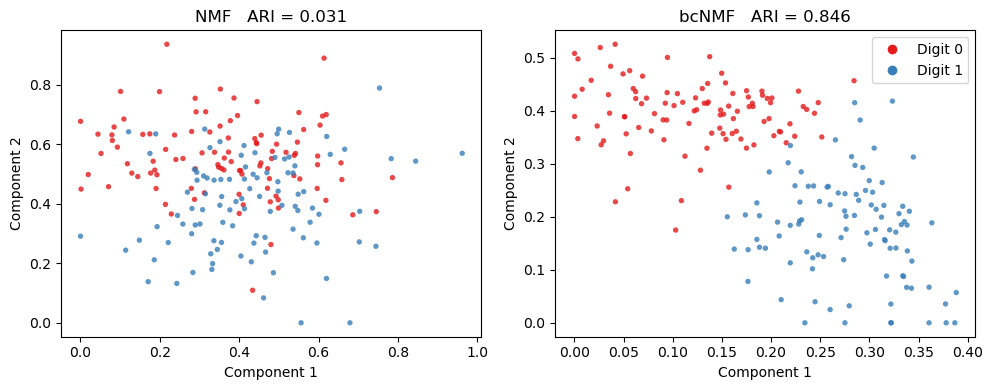

NMF   ARI: 0.0313
bcNMF ARI: 0.8456


In [41]:
km_nmf = KMeans(n_clusters=K, random_state=0, n_init=10).fit(H_nmf.T)
km_bc  = KMeans(n_clusters=K, random_state=0, n_init=10).fit(H_X_bc.T)

ari_nmf = adjusted_rand_score(labels, km_nmf.labels_)
ari_bc  = adjusted_rand_score(labels, km_bc.labels_)

colors     = ['#e41a1c', '#377eb8']
color_list = [colors[l] for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, H, title, ari in zip(
    axes,
    [H_nmf, H_X_bc],
    ['NMF', 'bcNMF'],
    [ari_nmf, ari_bc]
):
    ax.scatter(H[0], H[1], c=color_list, s=15, alpha=0.8, edgecolors='none')
    ax.set_title(f'{title}   ARI = {ari:.3f}', fontsize=12)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
                  markersize=8, label=f'Digit {d}') for d, c in enumerate(colors)]
axes[1].legend(handles=handles)

plt.tight_layout()
plt.savefig('results/nmf_vs_bcnmf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NMF   ARI: {ari_nmf:.4f}')
print(f'bcNMF ARI: {ari_bc:.4f}')

## Save result matrices

In [42]:
pd.DataFrame(H_nmf.T,  columns=[f'comp_{k}' for k in range(K)]).to_csv('results/H_nmf.csv',   index=False)
pd.DataFrame(H_X_bc.T, columns=[f'comp_{k}' for k in range(K)]).to_csv('results/H_bcnmf.csv', index=False)
pd.DataFrame({'method': ['NMF', 'bcNMF'], 'ARI': [ari_nmf, ari_bc]}).to_csv('results/ari_summary.csv', index=False)
print('Saved: results/H_nmf.csv  |  results/H_bcnmf.csv  |  results/ari_summary.csv')

Saved: results/H_nmf.csv  |  results/H_bcnmf.csv  |  results/ari_summary.csv
